### Data information

- Fish ID in the format 'YYYYMMDDNN' (year, month, day, zero-padded fish number; e.g. fish_1 on 2025_05_29 would be 20250529) <br>

- Video code in the format 'IDHHMMSS' (fish_ID, hour, minute, second) <br>

- Number of rows == number of frames in the video

#### Description of data in the "kinematics/code + .csv"
| Column name | Column data description |
| --- | --- |
| 'k0' - 'k(n-1)' | angle of tangents between n successive tail points |
| 'tip' | the average curvature (tail angle) over the last 20% of the tail|
| 'length' | the length of the tail (useful for finding tracking errors) |
| 'left' | the angle of the left eye relative to the heading |
| 'right' | the angle of the right eye relative to the heading |
| 'speed' | the instantaneous speed in each frame |
| 'angular_velocity' | the instantaneous angular velocity in each frame |
| 'tracked' | whether kinematic data exists from the frame |

note: refer to _'behavior_analysis/tracking/kinematics.py'_, lines 280-288

In [1]:
from behavior_analysis.experiment import BehaviorExperiment
import pandas as pd
import os
# Open experiment
experiment = BehaviorExperiment.open(r"C:\Users\manyung.ng\Documents\behaviour_analysis\behavior_analysis_tracking\mafaa_analysis")
print(experiment)
# Open video and bout info
video_info = pd.read_csv(experiment.directory.joinpath('video_data.csv'), dtype={'ID': str, 'code': str})
bouts_df = pd.read_csv(experiment.subdirs["analysis"].joinpath('bouts.csv'),
                        dtype={'ID': str, 'code': str})

eye_conv_path = os.path.join(experiment.subdirs['analysis'], 'eye_convergence')
convergence_scores_path = os.path.join(eye_conv_path, 'convergence_scores.csv')
convergence_scores = pd.read_csv(convergence_scores_path, dtype={'ID': str})

name: mafaa_analysis
date: 2025-06-30
animal_data: fish_data.csv
video_data: video_data.csv
mask_data: mask_data.csv
bout_detection: {'threshold': 0.02, 'winsize': 0.05}



In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import squareform
from pathlib import Path
import numpy as np
from behavior_analysis.analysis.csv import import_csvs

# plotting with seaborn
import seaborn as sns
# set figure size
sns.set_theme(rc={"figure.figsize": (15,5)})

### Import kinematics data and reformatting

#### option 1: collapse the multi-index format of the kinematics df

In [28]:
kinematics = import_csvs(experiment.subdirs['kinematics'], index_levels=(1,0), level_names=("ID", 'code', "frame"))

# convert frame number of each video (labelled by code) to time in minutes
# recorded 12 videos * 2.5 min per fish
# so there should be 12 distinct codes for one fish, 2.5 minutes max for one code
time = [] # list for one video
for code in kinematics.index.get_level_values('code').unique():
    fps = video_info[video_info['code'] == code].fps.squeeze()
    frame_num = kinematics.xs(code, level='code').index.get_level_values('frame')
    time.extend((frame_num/fps)/60)

retained_columns = ['ID', 'code', 'frame', 'speed', 'angular_velocity', 'tip', 'left_angle', 'right_angle']
kinematics = kinematics.reset_index().get(retained_columns) # get rid of multi-index format

kinematics['right_angle'] = kinematics['right_angle'].apply(np.degrees)
kinematics['left_angle'] = kinematics['left_angle'].apply(np.degrees)
kinematics['convergence'] = kinematics['right_angle'] - kinematics['left_angle']
kinematics['time'] = time # time (min) for each video segement of each fish is added

# combine the time for each video segement for one fish (labelled by ID) into a continuous time scale
# there's probably a smarter way to do this but this the best i can do without ai atm
# still proud of self ^v^
i = 0
time = [] # list for one fish
total_time = [] # master list for all fish
for code in kinematics['code'].unique():
    if i == 0:
        time.extend(kinematics[kinematics['code'] == code].time.squeeze())
        # print(i, code) # enable to troubleshoot
        i = i + 1
    elif (i >= 1) & (i <= 10):
        time.extend(kinematics[kinematics['code'] == code].time.squeeze() + max(time))
        # print(i, code)
        i = i + 1
    elif i == 11:
        time.extend(kinematics[kinematics['code'] == code].time.squeeze() + max(time))
        total_time.extend(time) # added the whole time line for one fish into the master list
        # print(i, code)
        time = [] # reset the time list for one fish
        i = 0 # reset counter

kinematics['time'] = total_time

kinematics['speed'] = kinematics['speed'].mask(kinematics['speed']>2000) # remove the frames with unrealistic speed

kinematics

Opening 528 csv files...


########### 10%
########### 20%
############ 30%
########### 40%
########### 50%
########### 60%
########### 70%
############ 80%
########### 90%
########### 100%
#done!
DataFrame has shape: (19809223, 57).
Index levels: ('ID', 'code', 'frame').



,ID,code,frame,speed,angular_velocity,tip,left_angle,right_angle,convergence,time
0,2025061201,2025061201134603.404,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,2025061201,2025061201134603.404,1,NaN,NaN,NaN,NaN,NaN,NaN,0.000067
2,2025061201,2025061201134603.404,2,NaN,NaN,NaN,NaN,NaN,NaN,0.000133
3,2025061201,2025061201134603.404,3,NaN,NaN,NaN,NaN,NaN,NaN,0.000200
4,2025061201,2025061201134603.404,4,NaN,NaN,NaN,NaN,NaN,NaN,0.000267
...,...,...,...,...,...,...,...,...,...,...
19809218,2025082209,2025082209221305.472,37511,0.0,0.0,-0.046282,-14.299659,16.358615,30.658274,30.004650
19809219,2025082209,2025082209221305.472,37512,0.0,0.0,-0.046282,-14.299659,16.358615,30.658274,30.004717
19809220,2025082209,2025082209221305.472,37513,0.0,0.0,-0.046282,-14.299659,16.346546,30.646205,30.004784
19809221,2025082209,2025082209221305.472,37514,0.0,0.0,-0.046282,-14.299659,16.334477,30.634136,30.004850


In [ ]:
# potentially problematic recordings that can be dropped.
drop_ID = ['2025081405', '2025081406', '2025081506', '2025081508', '2025082106', '2025082107', '2025082109', '2025082201', '2025082103', '2025082205', '2025082207', '2025082209']

#### option 2: retain the multi-index format of the kinematics df (potentially not useful lol)

In [3]:
kinematics = import_csvs(experiment.subdirs['kinematics'], index_levels=(1,0), level_names=("ID", 'code', "frame"))

# convert frame number of each video (labelled by code) to time in minutes
# recorded 12 videos * 2.5 min per fish
# so there should be 12 distinct codes for one fish, 2.5 minutes max for one code
time = [] # list for one video
for code in kinematics.index.get_level_values('code').unique():
    fps = video_info[video_info['code'] == code].fps.squeeze()
    frame_num = kinematics.xs(code, level='code').index.get_level_values('frame')
    time.extend((frame_num/fps)/60)

retained_columns = ['speed', 'angular_velocity', 'tip', 'left_angle', 'right_angle']
kinematics = kinematics.get(retained_columns) # get rid of unused columns

kinematics['right_angle'] = kinematics['right_angle'].apply(np.degrees)
kinematics['left_angle'] = kinematics['left_angle'].apply(np.degrees)
kinematics['convergence'] = kinematics['right_angle'] - kinematics['left_angle']
kinematics['time'] = time # time (min) for each video segement of each fish is added

# combine the time for each video segement for one fish (labelled by ID) into a continuous time scale
# there's probably a smarter way to do this but this the best i can do without ai atm
# still proud of self ^v^
i = 0
time = [] # list for one fish
total_time = [] # master list for all fish
for code in kinematics.index.get_level_values('code').unique():
    if i == 0:
        time.extend(kinematics.xs(code, level='code').time.squeeze())
        # print(i, code) # enable to troubleshoot
        i = i + 1
    elif (i >= 1) & (i <= 10):
        time.extend(kinematics.xs(code, level='code').time.squeeze() + max(time))
        # print(i, code)
        i = i + 1
    elif i == 11:
        time.extend(kinematics.xs(code, level='code').time.squeeze() + max(time))
        total_time.extend(time) # added the whole time line for one fish into the master list
        # print(i, code)
        time = [] # reset the time list for one fish
        i = 0 # reset counter

kinematics['time'] = total_time

kinematics['speed'] = kinematics['speed'].mask(kinematics['speed']>2000) # remove the frames with unrealistic speed

kinematics

Opening 528 csv files...
########### 10%
########### 20%
############ 30%
########### 40%
########### 50%
########### 60%
########### 70%
############ 80%
########### 90%
########### 100%
#done!
DataFrame has shape: (19809223, 57).
Index levels: ('ID', 'code', 'frame').



speed  angular_velocity       tip  \
ID         code                 frame                                      
2025061201 2025061201134603.404 0        NaN               NaN       NaN   
                                1        NaN               NaN       NaN   
                                2        NaN               NaN       NaN   
                                3        NaN               NaN       NaN   
                                4        NaN               NaN       NaN   
...                                      ...               ...       ...   
2025082209 2025082209221305.472 37511    0.0               0.0 -0.046282   
                                37512    0.0               0.0 -0.046282   
                                37513    0.0               0.0 -0.046282   
                                37514    0.0               0.0 -0.046282   
                                37515    NaN               NaN -0.046282   

                                       left_angle  right_angle  convergence  \
ID         code                 frame                                         
2025061201 2025061201134603.404 0             NaN          NaN          NaN   
                                1             NaN          NaN          NaN   
                                2             NaN          NaN          NaN   
                                3             NaN          NaN          NaN   
                                4             NaN          NaN          NaN   
...                                           ...          ...          ...   
2025082209 2025082209221305.472 37511  -14.299659    16.358615    30.658274   
                                37512  -14.299659    16.358615    30.658274   
                                37513  -14.299659    16.346546    30.646205   
                                37514  -14.299659    16.334477    30.634136   
                                37515  -14.299659    16.334477    30.634136   

                                            time  
ID         code                 frame             
2025061201 2025061201134603.404 0       0.000000  
                                1       0.000067  
                                2       0.000133  
                                3       0.000200  
                                4       0.000267  
...                                          ...  
2025082209 2025082209221305.472 37511  30.004650  
                                37512  30.004717  
                                37513  30.004784  
                                37514  30.004850  
                                37515  30.004917  

[19809223 rows x 7 columns]

In [ ]:
# check the speed distribution across all fish
sns.histplot(data=kinematics[kinematics['speed']<5000], x='speed', stat='percent', kde=True, bins=100)

In [4]:
bout_convergence_label = pd.read_csv(os.path.join(experiment.subdirs['analysis'], 'bout_convergence_labels.csv'), dtype={'ID': str, 'code': str})
bout_convergence_label = bout_convergence_label.melt(
    id_vars= ['ID', 'code', 'phase'],
    value_vars= ['start', 'end'],
    var_name= 'bout_label',
    value_name= 'frame'
    )
bout_convergence_label

,ID,code,phase,bout_label,frame
0,2025061201,2025061201134603.404,0.0,start,14
1,2025061201,2025061201134603.404,0.0,start,70
2,2025061201,2025061201134603.404,0.0,start,154
3,2025061201,2025061201134603.404,0.0,start,363
4,2025061201,2025061201134603.404,0.0,start,400
...,...,...,...,...,...
274803,2025082209,2025082209221305.472,0.0,end,35717
274804,2025082209,2025082209221305.472,0.0,end,35980
274805,2025082209,2025082209221305.472,0.0,end,36428
274806,2025082209,2025082209221305.472,0.0,end,36834


compatible with kinematics df options 1 and 2:

In [5]:
kinematics_bout_label = pd.merge(kinematics, bout_convergence_label, how='left', on=['ID', 'code', 'frame'])
kinematics_bout_label['tip'] = kinematics_bout_label['tip'].apply(np.degrees)
kinematics_bout_label

,ID,code,frame,speed,angular_velocity,tip,left_angle,right_angle,convergence,time,phase,bout_label
0,2025061201,2025061201134603.404,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
1,2025061201,2025061201134603.404,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000067,NaN,NaN
2,2025061201,2025061201134603.404,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000133,NaN,NaN
3,2025061201,2025061201134603.404,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000200,NaN,NaN
4,2025061201,2025061201134603.404,4.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000267,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19809218,2025082209,2025082209221305.472,37511.0,0.0,0.0,-2.651775,-14.299659,16.358615,30.658274,30.004650,NaN,NaN
19809219,2025082209,2025082209221305.472,37512.0,0.0,0.0,-2.651775,-14.299659,16.358615,30.658274,30.004717,NaN,NaN
19809220,2025082209,2025082209221305.472,37513.0,0.0,0.0,-2.651775,-14.299659,16.346546,30.646205,30.004784,NaN,NaN
19809221,2025082209,2025082209221305.472,37514.0,0.0,0.0,-2.651775,-14.299659,16.334477,30.634136,30.004850,NaN,NaN


#### mean of speed and angular velocity for each of the fish

compatible with kinematics option 1:

In [181]:
general_stats = kinematics['speed'].groupby(kinematics['ID']).mean().to_frame().reset_index()
general_stats['angular_velocity'] = np.array(kinematics['angular_velocity'].groupby(kinematics['ID']).mean())
general_stats['eye_convergence'] = np.array(kinematics['convergence'].groupby(kinematics['ID']).mean())
general_stats['condition'] = experiment.animal_data['condition']
general_stats

,ID,speed,angular_velocity,eye_convergence,condition
0,2025061201,159.660682,-0.103657,16.297178,"NTR-, Ron-"
1,2025061202,275.848992,-0.082205,37.326533,"NTR+, Ron+"
2,2025061203,299.187113,0.008431,46.453241,"NTR-, Ron+"
3,2025061204,303.393180,-0.025510,36.358390,"NTR+, Ron-"
4,2025061205,302.638193,0.055011,35.419477,"NTR+, Ron+"
5,2025061206,293.183021,0.016067,38.316104,"NTR+, Ron-"
6,2025061207,381.409615,0.044243,37.248615,"NTR+, Ron+"
7,2025061208,363.636192,0.153141,50.063309,"NTR+, Ron+"
8,2025081401,134.873310,-0.043310,2.018526,"NTR-, Ron-"
9,2025081402,254.556365,-0.069933,29.297501,"NTR+, Ron+"



compatible with kinematics df option 2 (multi-index):

In [4]:
general_stats = kinematics['speed'].groupby("ID").mean().to_frame().reset_index()
general_stats['angular_velocity'] = np.array(kinematics['angular_velocity'].groupby("ID").mean())
general_stats['eye_convergence'] = np.array(kinematics['convergence'].groupby("ID").mean())
general_stats['condition'] = experiment.animal_data['condition']
general_stats

,ID,speed,angular_velocity,eye_convergence,condition
0,2025061201,159.660682,-0.103657,16.297178,"NTR-, Ron-"
1,2025061202,275.848992,-0.082205,37.326533,"NTR+, Ron+"
2,2025061203,299.187113,0.008431,46.453241,"NTR-, Ron+"
3,2025061204,303.393180,-0.025510,36.358390,"NTR+, Ron-"
4,2025061205,302.638193,0.055011,35.419477,"NTR+, Ron+"
5,2025061206,293.183021,0.016067,38.316104,"NTR+, Ron-"
6,2025061207,381.409615,0.044243,37.248615,"NTR+, Ron+"
7,2025061208,363.636192,0.153141,50.063309,"NTR+, Ron+"
8,2025081401,134.873310,-0.043310,2.018526,"NTR-, Ron-"
9,2025081402,254.556365,-0.069933,29.297501,"NTR+, Ron+"


compatible with kinematics df options 1 and 2:

In [258]:
con = kinematics.query('time>=0.0 & time<=5.1').groupby('ID').convergence.mean().to_frame().reset_index()
con = con.rename(columns={'convergence':'0-5 min'})
con['5.5-15.5 min'] = kinematics.query('time>=5.5 & time<=15.5').groupby('ID').convergence.mean().to_list()
con['15.5-30 min'] = kinematics.query('time>=15.5 & time<=30.1').groupby('ID').convergence.mean().to_list()
con['5.5-30 min'] = kinematics.query('time>=5.5 & time<=30.1').groupby('ID').convergence.mean().to_list()
con['threshold'] = convergence_scores['threshold']
con['condition'] = experiment.animal_data['condition']
con = con[con['5.5-15.5 min'] >10].reset_index()
# con.to_csv(os.path.join(experiment.subdirs['analysis'], 'convergence_stat.csv'))
# con.to_csv(os.path.join(experiment.subdirs['analysis'], 'convergence_stat_filtered.csv'))

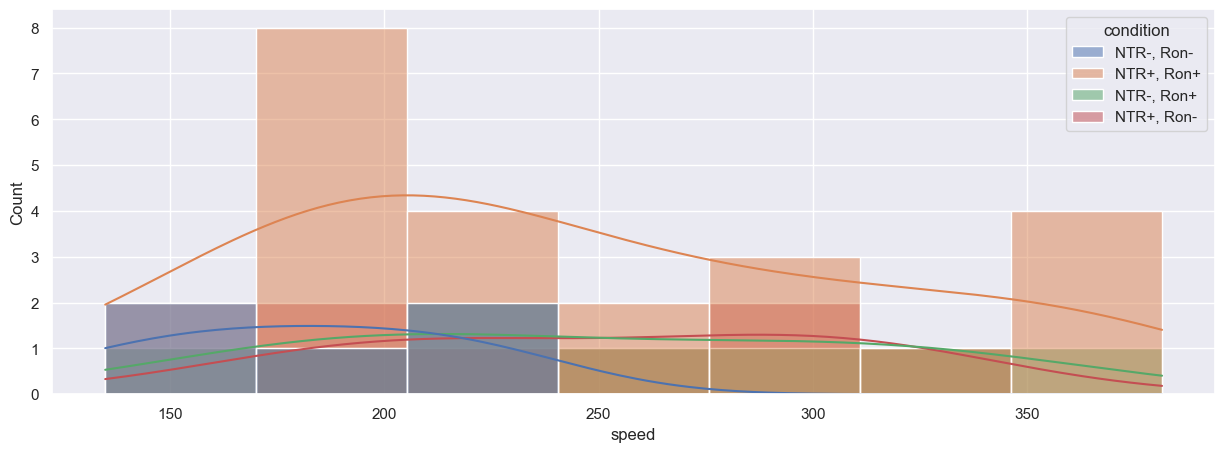

In [26]:
sns.histplot(general_stats, x='speed', kde=True, hue='condition')

#### To plot the duration of each fish spending in the outer and inner rim of the arena <br>
The arena is separated into 3 portions, from circle centre to 1/3 of radius, 1/3 radius to 2/3 radius, 2/3 radius to radius <br>

The fish location is calculated for each frame, relative to the coordinates of the circle centre

In [31]:
# function for calculating distance given coordinates of 2 points
import math
def get_distance(point_a, point_b):
    x1, y1 = point_a
    x2, y2 = point_b
    return math.hypot(x1 - x2, y1 - y2)

# dataframe of the fish location in coordinates
fish_loc = import_csvs(experiment.subdirs['tracking'], index_levels=(1,0), level_names=("ID", 'code', "frame"))
fish_loc = fish_loc.reset_index()
fish_loc['time'] = kinematics['time'] # goes first if the kinematics df is multi-index, otherwise, reset_index() first
fish_loc['condition'] = filter_df.reset_index()['condition'] # need reset_index() if filter_df is multi-index
retained_columns = ['ID', 'condition', 'time', 'x', 'y']
fish_loc = fish_loc.get(retained_columns)

# compute distance of the fish from the centre of the circle
# append it to fish_loc df
dist_ls = []
counter = 0
total_counter = 0
for ID in fish_loc['ID'].unique():
   total_counter = total_counter + counter
   fish_idx = fish_loc[fish_loc['ID'] == ID].index.max() + 1
   centre = (experiment.mask_data[experiment.mask_data['ID'] == ID].center_x.squeeze(), experiment.mask_data[experiment.mask_data['ID'] == ID].center_y.squeeze())
   fish_x = np.array(fish_loc['x'][total_counter:fish_idx])
   fish_y = np.array(fish_loc['y'][total_counter:fish_idx])
   # print(f"list is from {total_counter}:{fish_idx}") # to check whether the indexing is correct
   counter = 0
   while counter < len(fish_x):
      dist_ls.append(get_distance((fish_x[counter], fish_y[counter]), centre))
      counter += 1
# print(total_counter, counter, len(dist_ls)) # to check if the final output is in the correct length
fish_loc['dist'] = dist_ls

# calculate the percentage of frames each fish spent in a given distance relative to the circle centre
dist_count = pd.DataFrame()
for ID in fish_loc['ID'].unique():
    # make unique bins for each of the fish ID based on the radius.
    radius = experiment.mask_data[experiment.mask_data['ID'] == ID].radius.squeeze()
    bin = [0, radius/3, (radius/3)*2, radius] # make 3 bins of distances from the centre to the rim of the circle
    # count the frames of the fish in each bin
    value_count = fish_loc[fish_loc['ID'] == ID].dist.value_counts(bins=bin).to_frame().reset_index()
    value_count['dist'] = (value_count['dist']/value_count.dist.sum())*100 # convert the count into percentage
    value_count['ID'] = ID # add the ID of the fish for later df reorganization
    value_count = value_count.sort_values(by='index', axis=0) # sort the range from innermost to outermost distance to circle centre
    value_count['index'] = ['inner', 'middle', 'outer'] # rename the index name for concat and pivot the df
    dist_count = pd.concat([dist_count, value_count])
# recorganise for easy plotting
dist_count.rename(columns={'index': 'location', 'dist': 'percentage'}, inplace=True)
dist_count = dist_count.pivot(index='ID', columns='location', values='percentage').reset_index()
dist_count['condition'] = general_stats['condition']
dist_count = dist_count.melt(
    id_vars = ['ID', 'condition'],
    value_vars = ['inner', 'middle', 'outer'],
    var_name = "location",
    value_name = "percentage"
).sort_values(by='ID').reset_index(drop=True)


Opening 528 csv files...
########### 10%
########### 20%
############ 30%
########### 40%
########### 50%
########### 60%
########### 70%
############ 80%
########### 90%
########### 100%
#done!
DataFrame has shape: (19809223, 10).
Index levels: ('ID', 'code', 'frame').



In [ ]:
cond_ls = []
for ID in test['ID']:
    cond_ls.append(general_stats[general_stats['ID'] == ID]['condition'])
cond_ls

[0    NTR-, Ron-
 Name: condition, dtype: object,
 1    NTR+, Ron+
 Name: condition, dtype: object,
 2    NTR-, Ron+
 Name: condition, dtype: object,
 3    NTR+, Ron-
 Name: condition, dtype: object,
 4    NTR+, Ron+
 Name: condition, dtype: object,
 5    NTR+, Ron-
 Name: condition, dtype: object,
 6    NTR+, Ron+
 Name: condition, dtype: object,
 7    NTR+, Ron+
 Name: condition, dtype: object,
 8    NTR-, Ron-
 Name: condition, dtype: object,
 9    NTR+, Ron+
 Name: condition, dtype: object,
 10    NTR+, Ron-
 Name: condition, dtype: object,
 11    NTR+, Ron+
 Name: condition, dtype: object,
 12    NTR+, Ron+
 Name: condition, dtype: object,
 13    NTR+, Ron+
 Name: condition, dtype: object,
 14    NTR+, Ron+
 Name: condition, dtype: object,
 15    NTR+, Ron+
 Name: condition, dtype: object,
 16    NTR-, Ron+
 Name: condition, dtype: object,
 17    NTR-, Ron-
 Name: condition, dtype: object,
 18    NTR+, Ron+
 Name: condition, dtype: object,
 19    NTR-, Ron+
 Name: condition, dtype

In [ ]:
id_dict = {}
id_ls = []
c = ""
for condition, ID in filtered_ID.index:
    c = condition
    if c == condition:
        id_ls.extend(filtered_ID.xs(condition, level='condition').index.get_level_values('ID'))
        id_dict.update({condition:id_ls})
        id_ls = []
    elif c != condition:
        id_ls = []
        id_ls.extend(filtered_ID.xs(condition, level='condition').index.get_level_values("ID"))
        id_dict.update({condition:id_ls})
        c = condition

id_ls = []
for values in id_dict.values():
    id_ls.extend(values) # make a continuous list of all retained IDs

retained_columns = ['ID', 'speed', 'convergence', 'time'] # modify if use the non-multi-index kinematics df to get ID as well
filter_df = kinematics.get(retained_columns) # get only the columns used for plotting

for ID in filter_df['ID'].unique():
    if ID not in id_ls:
        filter_df = filter_df[filter_df['ID'] != ID] # remove rows of filtered out IDs from the df
    for key in id_dict.keys():
        if ID in id_dict[key]:
            filter_df.loc[(filter_df['ID'] == ID), 'condition'] = str(key)
filter_df.set_index(['ID', 'condition'], inplace=True)
filter_df.index = filter_df.index.swaplevel(0,1) # multi-index, first condition, then ID (but the ID formatting is still not very good.)

In [244]:
# some fish might be dropped due to poor quality (in recording, ablation etc.)
drop_ID = ['2025081405', '2025081406', '2025081506', '2025081508', '2025082106', '2025082107', '2025082109', '2025082201', '2025082103', '2025082205', '2025082207', '2025082209']
test = dist_count
for ID in drop_ID:
    test = test[test['ID'] != ID]
test

,ID,condition,location,percentage
0,2025061201,"NTR-, Ron-",inner,1.553949
1,2025061201,"NTR-, Ron-",middle,10.269122
2,2025061201,"NTR-, Ron-",outer,88.176929
3,2025061202,"NTR+, Ron+",inner,13.429390
4,2025061202,"NTR+, Ron+",middle,46.364646
...,...,...,...,...
121,2025082206,"NTR-, Ron-",middle,50.361949
122,2025082206,"NTR-, Ron-",inner,22.868452
126,2025082208,"NTR+, Ron-",outer,63.245374
127,2025082208,"NTR+, Ron-",inner,7.544701


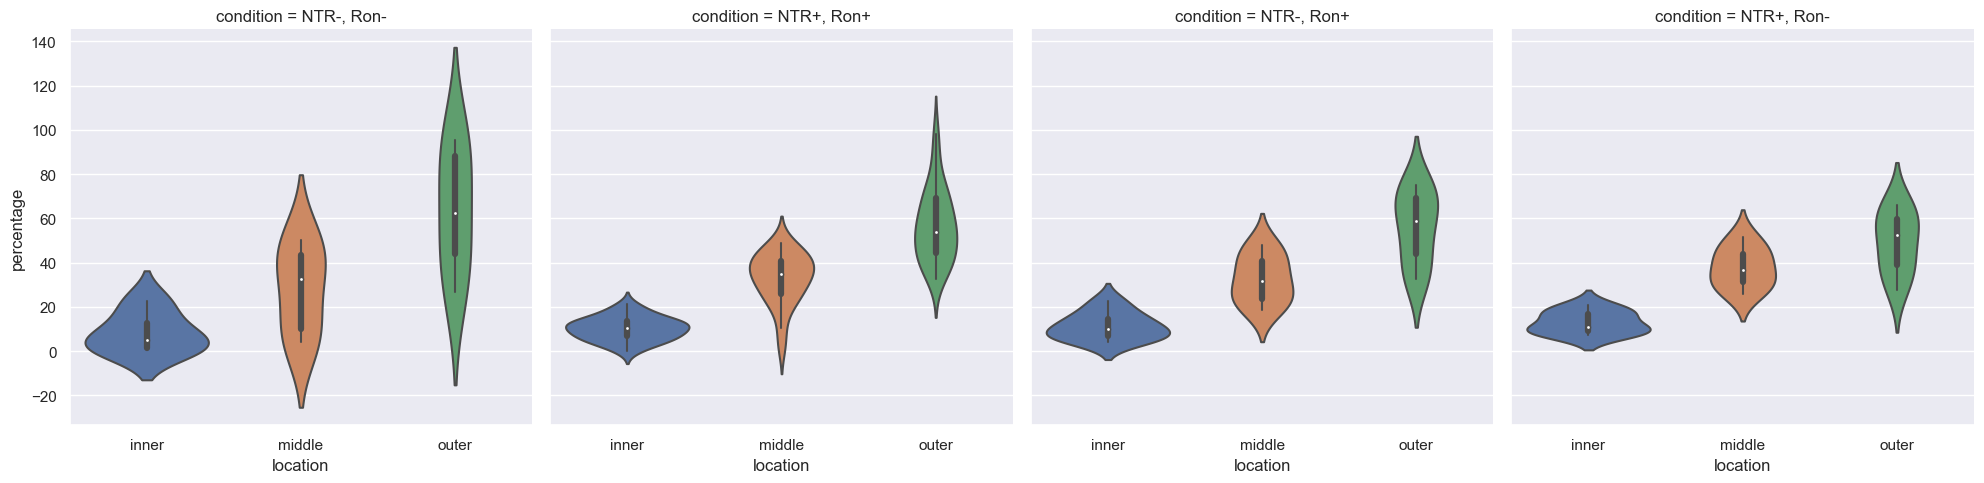

In [242]:
sns.catplot(
    dist_count, kind='violin',
    x='location', y='percentage', col='condition'
)

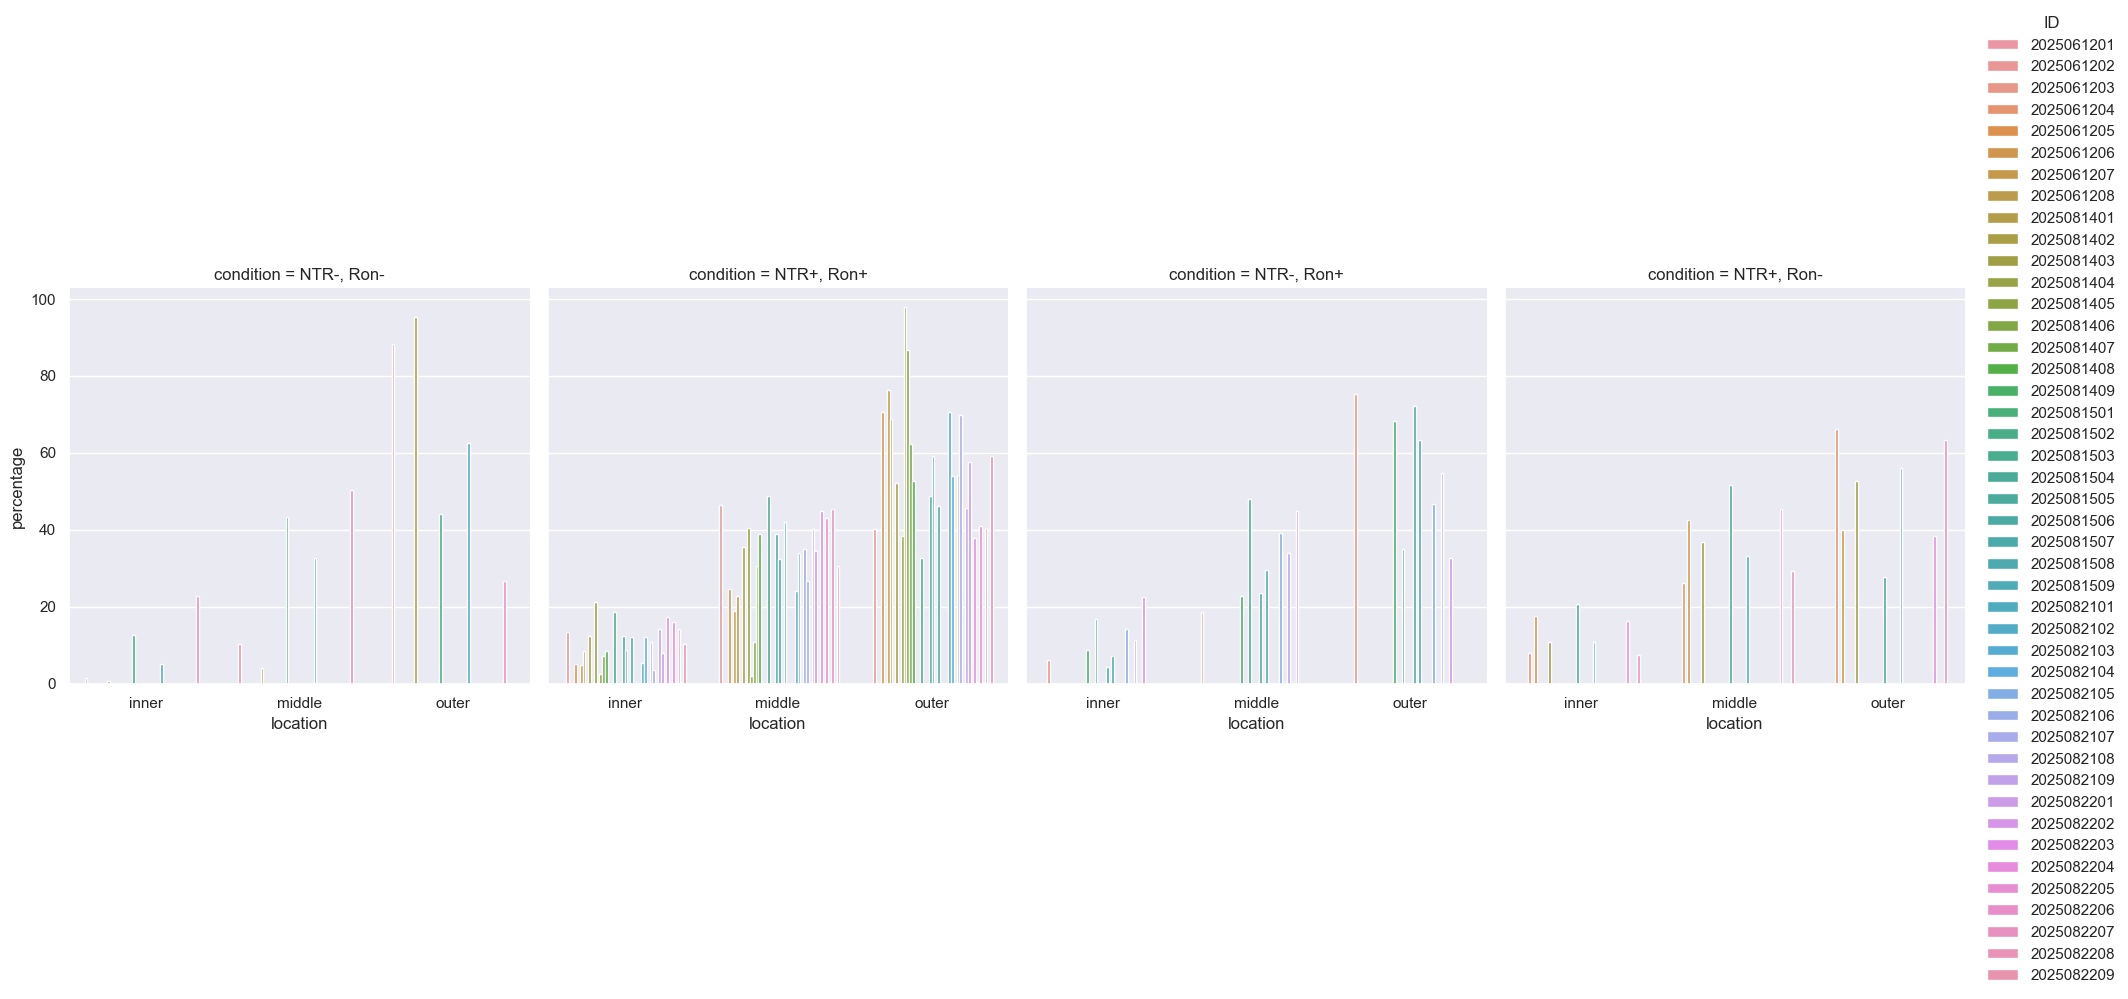

In [225]:
sns.catplot(dist_count, kind='bar', x='location', y='percentage', col='condition', hue='ID')

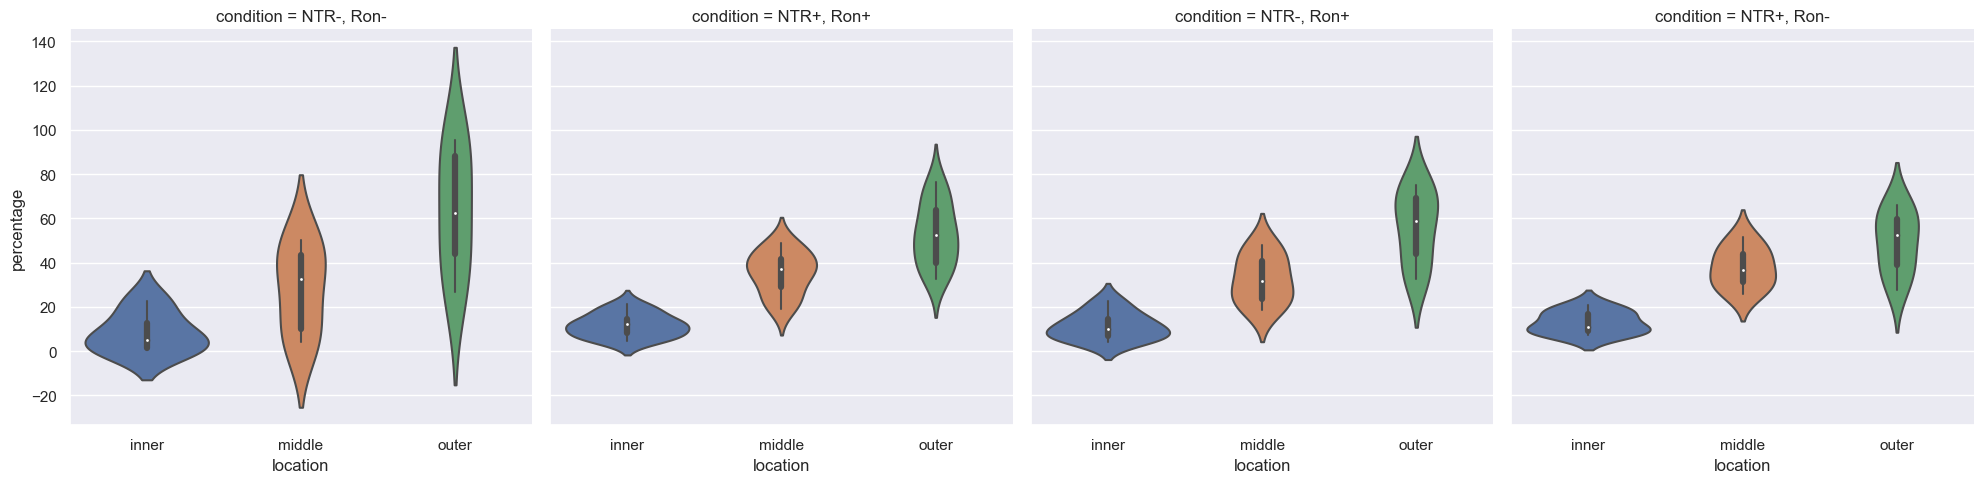

In [248]:
sns.catplot(
    test, kind='violin',
    x='location', y='percentage', col='condition'
)

This is highly likely to be abandoned lol <br>
all that work for nothing haha

c:\Users\manyung.ng\AppData\Local\anaconda3\envs\behavior_analysis\lib\site-packages\pandas\core\indexing.py:1684: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = infer_fill_value(value)
c:\Users\manyung.ng\AppData\Local\anaconda3\envs\behavior_analysis\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


'### this chunk is for multi-index kinematics df\nfilter_df = pd.DataFrame()\nfor ID in id_ls:\n    filter_df = pd.concat([filter_df, sub_df.loc[ID]])\n    for key in d.keys():\n        if ID in d[key]:\n            filter_df.loc[ID, \'condition\'] = str(key)\nfilter_df = filter_df.set_index("condition", append=True)\nfilter_df = filter_df.swaplevel()\n###'

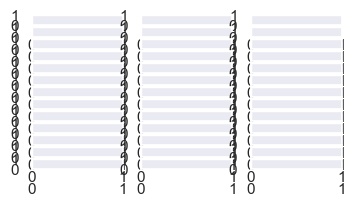

In [ ]:
# sns.set_theme(rc={"figure.figsize": (4,2)})
# fig, axs = plt.subplots(13,3)

# first extract the fish IDs with average speed (of the whole recording) <1000
# then for every fish ID, plot out the speed graph
# format them so that it fits in the 13x3 format.
# shrink the size of each subplot probably helps too
# probably have to make for loop with a counter to fit in a subplot format.

# filtered the data by the average speed of each fish (speed > 1000 mostly means the tracking wasn't good)
#### I have modified it so that the frames with abnormal speed are now NaN in the kinematics df, so this is kind of useless now.
# stored IDs in a dict according to the fish condition (genotype, treatment)
filtered_ID = general_stats[general_stats['speed']<1000].groupby(['condition', 'ID']).sum()
id_dict = {}
id_ls = []
c = ""
for condition, ID in filtered_ID.index:
    c = condition
    if c == condition:
        id_ls.extend(filtered_ID.xs(condition, level='condition').index.get_level_values('ID'))
        id_dict.update({condition:id_ls})
        id_ls = []
    elif c != condition:
        id_ls = []
        id_ls.extend(filtered_ID.xs(condition, level='condition').index.get_level_values("ID"))
        id_dict.update({condition:id_ls})
        c = condition

id_ls = []
for values in id_dict.values():
    id_ls.extend(values) # make a continuous list of all retained IDs

retained_columns = ['ID', 'speed', 'convergence', 'time'] # modify if use the non-multi-index kinematics df to get ID as well
filter_df = kinematics.get(retained_columns) # get only the columns used for plotting


# this is for non-multi-index kinematics df #
# if it doesn't work, probably because i switched to working with multi-index and didn't test it after #

# filter_df = pd.DataFrame()
for ID in filter_df['ID'].unique():
    if ID not in id_ls:
        filter_df = filter_df[filter_df['ID'] != ID] # remove rows of filtered out IDs from the df
    for key in id_dict.keys():
        if ID in id_dict[key]:
            filter_df.loc[(filter_df['ID'] == ID), 'condition'] = str(key)
filter_df.set_index(['ID', 'condition'], inplace=True)
filter_df.index = filter_df.index.swaplevel(0,1) # multi-index, first condition, then ID (but the ID formatting is still not very good.)


"""### this chunk is for multi-index kinematics df
filter_df = pd.DataFrame()
for ID in id_ls:
    filter_df = pd.concat([filter_df, sub_df.loc[ID]])
    for key in d.keys():
        if ID in d[key]:
            filter_df.loc[ID, 'condition'] = str(key)
filter_df = filter_df.set_index("condition", append=True)
filter_df = filter_df.swaplevel()
###"""



# # plot speed over time in a session
# # vertical gray dash line is roughly when the paramecia is added (5 min after recording started)
# # horizontal black dash line is the convergence threshold for that fish
# sns.lineplot(data=sub_df, x='time', y="speed", legend='auto')
# # sns.scatterplot(data=sub_df, x='time', y="speed", hue='bout_label', legend="auto", hue_order=['start', 'end'], zorder=3) # bout start and end
# plt.axhline(y=sub_df.speed.mean(), linestyle='--', c='black')
# # plt.axvline(x=250*150*2, linestyle='--', c='gray') # rough timepoint of when paramecia were introduced
# plt.axvline(x=5.198979, linestyle='--', c='gray') # manual searched the paramecia entry time point
# plt.xlabel('time (min)')
# plt.ylabel('speed')


# for ax in axs.flat:
#     ax.set(xlabel='time', ylabel='speed')

# # Hide x labels and tick labels for top plots and y ticks for right plots.
# for ax in axs.flat:
#     ax.label_outer()

### Some general stats across the whole recording session

In [40]:
ID = '2025082109' # change ID number here
# define sub dataframe for one fish
sub_df = kinematics_bout_label[kinematics_bout_label['ID'] == ID].reset_index()

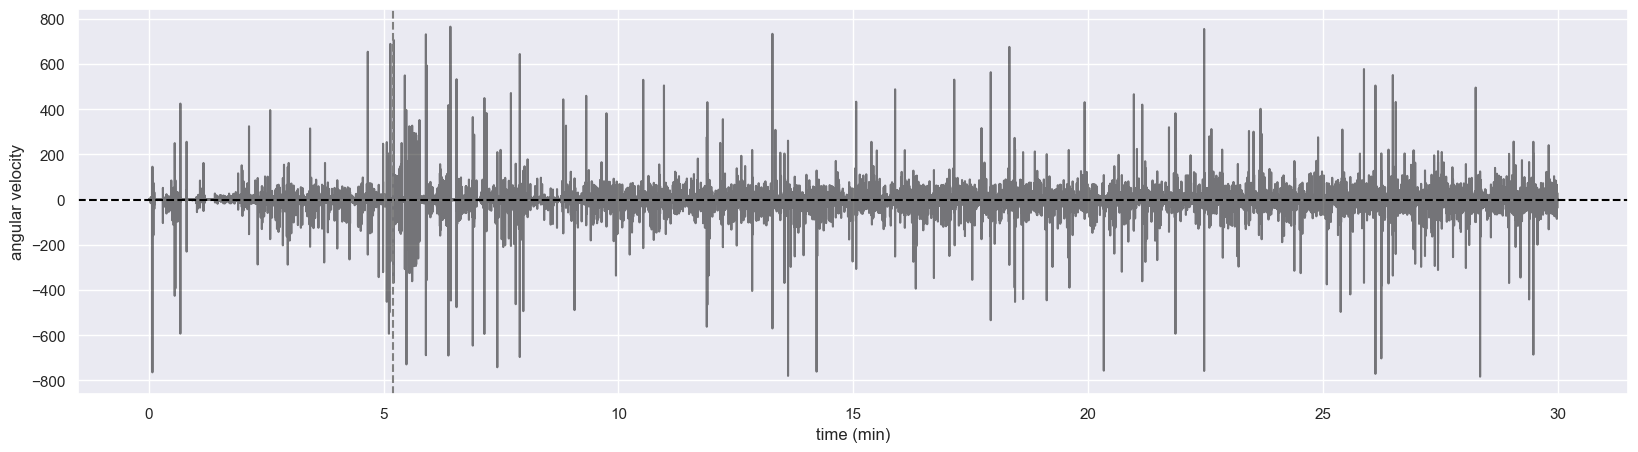

In [42]:
sns.set_theme(rc={"figure.figsize": (20,5)})
# plot angular velocity over time in a session
# vertical gray dash line is roughly when the paramecia is added (5 min after recording started)
# horizontal black dash line is the convergence threshold for that fish
sns.lineplot(data=sub_df, x='time', y="angular_velocity", legend='auto', alpha=0.5, color='black')
# sns.scatterplot(data=sub_df, x='time', y="angular_velocity", hue='bout_label', legend="auto", hue_order=['start', 'end'], zorder=3) # bout start and end
plt.axhline(y=sub_df[sub_df['ID'] == ID].angular_velocity.mean(), linestyle='--', c='black')
plt.axvline(x=5.198979, linestyle='--', c='gray') # rough timepoint of when paramecia were introduced
plt.xlabel('time (min)')
plt.ylabel('angular velocity')
plt.show()

In [ ]:
5.198979 (2025061207 para in)
5.672224 (2025061203 para in)

Text(0, 0.5, 'speed')

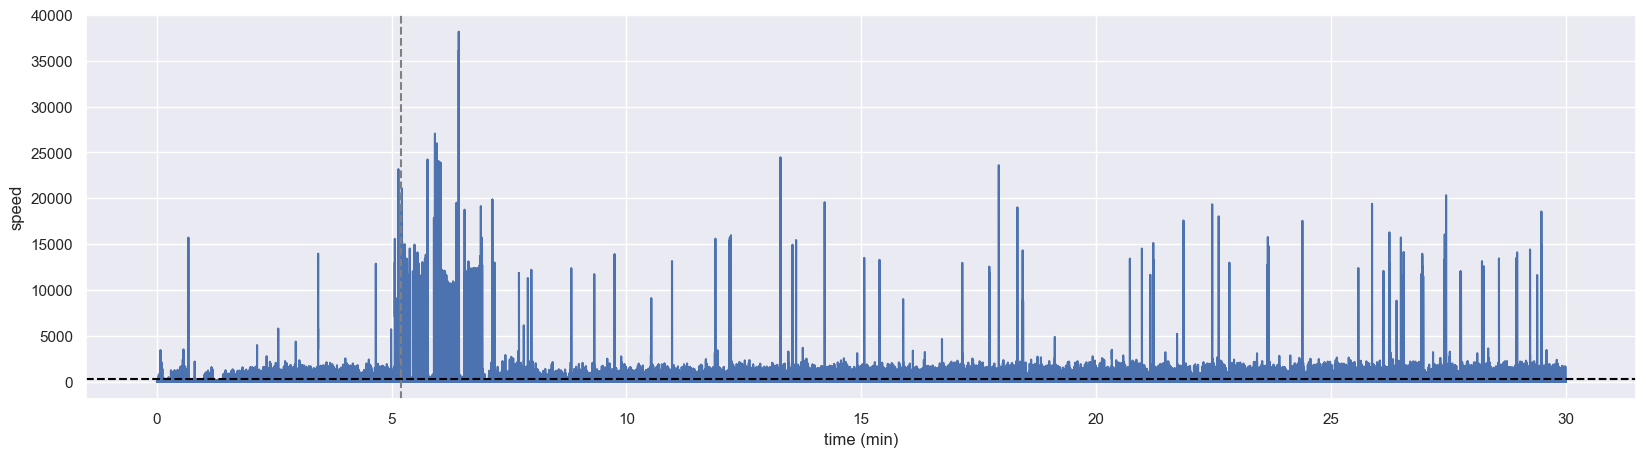

In [45]:
# plot speed over time in a session
# vertical gray dash line is roughly when the paramecia is added (5 min after recording started)
# horizontal black dash line is the convergence threshold for that fish
sns.lineplot(data=sub_df, x='time', y="speed", legend='auto')
# sns.scatterplot(data=sub_df, x='time', y="speed", hue='bout_label', legend="auto", hue_order=['start', 'end'], zorder=3) # bout start and end
plt.axhline(y=sub_df.speed.mean(), linestyle='--', c='black')
# plt.axvline(x=250*150*2, linestyle='--', c='gray') # rough timepoint of when paramecia were introduced
plt.axvline(x=5.198979, linestyle='--', c='gray') # manual searched the paramecia entry time point
plt.xlabel('time (min)')
plt.ylabel('speed')

Text(0, 0.5, 'convergence (degrees)')

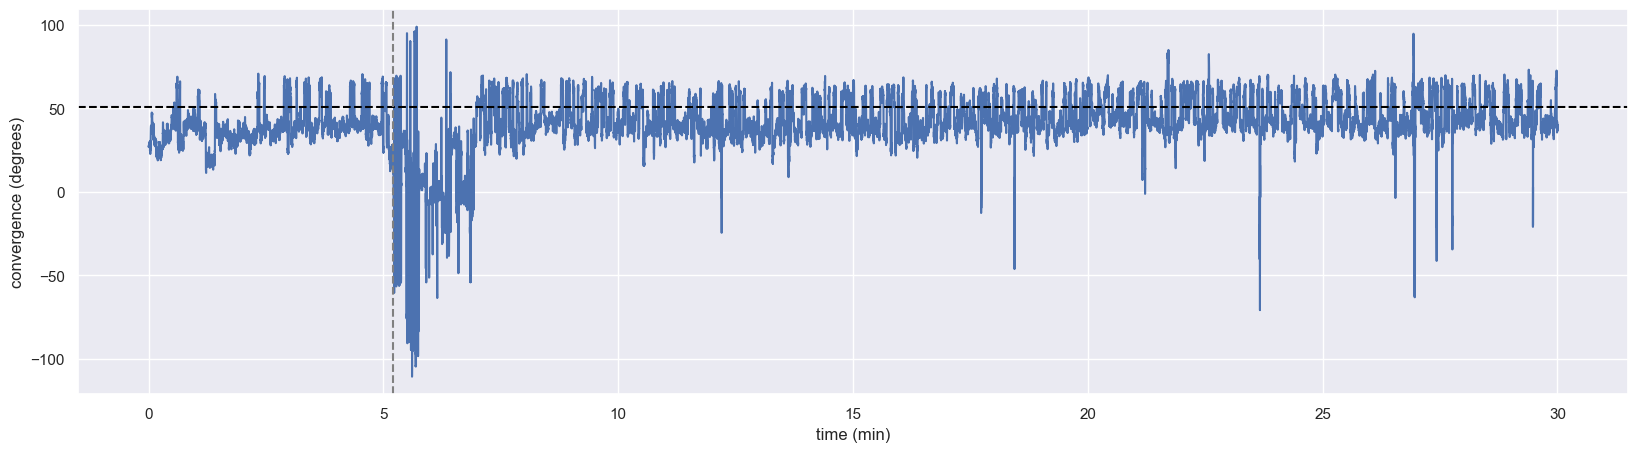

In [49]:
# plot eye convergence over time in a session
# vertical gray dash line is roughly when the paramecia is added (5 min after recording started)
# horizontal black dash line is the convergence threshold for that fish
sns.lineplot(data=sub_df, x='time', y="convergence", legend='auto')
# sns.scatterplot(data=sub_df, x='time', y="speed", hue='bout_label', legend="auto", hue_order=['start', 'end'], zorder=3) # bout start and end
plt.axhline(y=convergence_scores[convergence_scores['ID'] == ID].threshold.squeeze(), linestyle='--', c='black')
# plt.axvline(x=5, linestyle='--', c='gray') # rough timepoint of when paramecia were introduced
plt.axvline(x=5.198979, linestyle='--', c='gray') # manual searched the paramecia entry time point
plt.xlabel('time (min)')
plt.ylabel('convergence (degrees)')

### Manual search, plot fish tail curve, eye convergence angles

In [99]:
ID = '2025061203' # change ID number here
# define sub dataframe for one fish
sub_df = kinematics_bout_label[kinematics_bout_label['ID'] == ID].reset_index()
sub_df['time_ms'] = sub_df['time']*60*1000

In [125]:
# search for the indices of the frames of interest in a particular video
sub_df[(sub_df['code'] == '2025061203151944.800') & (sub_df['frame'] >= 28388)]

,index,ID,code,frame,speed,angular_velocity,tip,left_angle,right_angle,convergence,time,phase,bout_label,time_ms
103426,1003851,2025061203,2025061203151944.800,28388,143.810279,0.000000,-34.311603,-31.975952,26.620825,58.596777,6.893180,NaN,NaN,413590.777543
103427,1003852,2025061203,2025061203151944.800,28389,515.258992,-6.317262,-60.380863,-32.063492,27.181033,59.244526,6.893246,NaN,NaN,413594.776526
103428,1003853,2025061203,2025061203151944.800,28390,250.299166,0.000000,-68.783623,-32.164607,27.233017,59.397623,6.893313,NaN,NaN,413598.775508
103429,1003854,2025061203,2025061203151944.800,28391,147.073790,1.527869,-65.346106,-32.331794,28.017199,60.348993,6.893380,NaN,NaN,413602.774491
103430,1003855,2025061203,2025061203151944.800,28392,337.154224,14.059812,-60.004279,-32.521278,28.758515,61.279793,6.893446,NaN,NaN,413606.773474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112550,1012975,2025061203,2025061203151944.800,37512,264.733372,-8.548098,19.069334,-20.919517,27.720594,48.640111,7.501292,NaN,NaN,450077.494884
112551,1012976,2025061203,2025061203151944.800,37513,317.326384,-10.566657,18.669030,-20.919517,27.720594,48.640111,7.501358,NaN,NaN,450081.493867
112552,1012977,2025061203,2025061203151944.800,37514,462.147385,-4.440194,-3.920065,-20.844526,27.720594,48.565120,7.501425,NaN,NaN,450085.492850
112553,1012978,2025061203,2025061203151944.800,37515,343.583295,-1.927212,-21.784236,-20.769536,27.720594,48.490129,7.501492,NaN,NaN,450089.491832


In [101]:
sns.set_theme(rc={"figure.figsize": (20,5)})

Text(0, 0.5, 'Tail angle (degrees)')

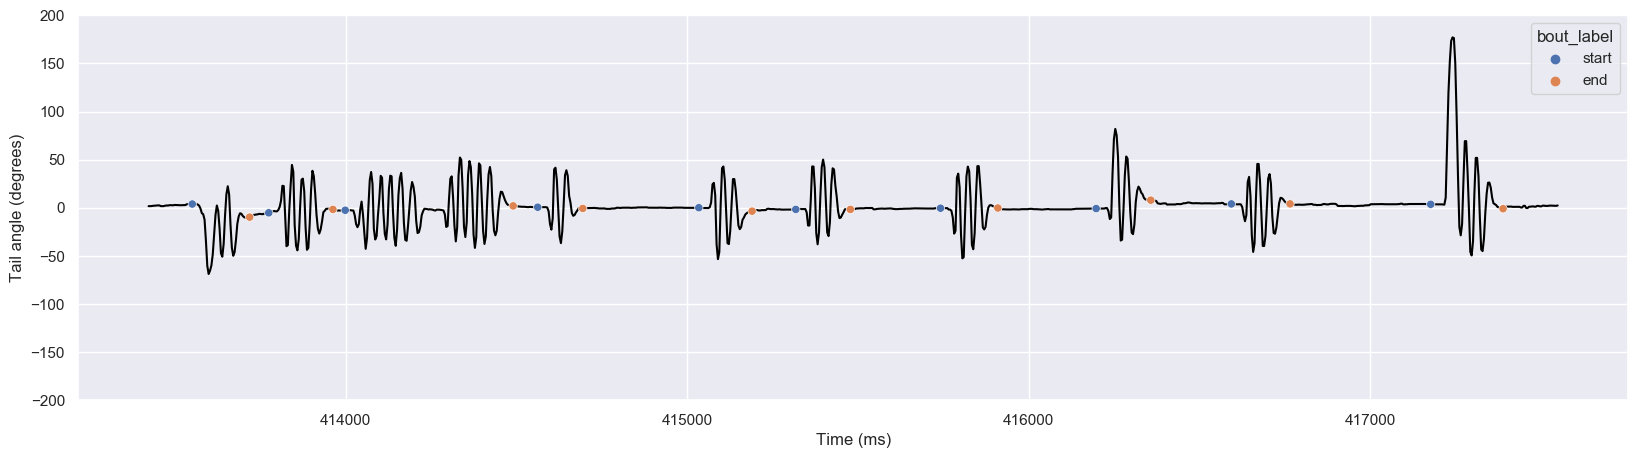

In [110]:
boi = sub_df[103384:104417] # bout of interest
# plot tip angle over time in a session
# vertical gray dash line is roughly when the paramecia is added (5 min after recording started)
# horizontal black dash line is the convergence threshold for that fish
sns.lineplot(data=boi, x='time_ms', y="tip", legend='auto', color='black', zorder=2)
sns.scatterplot(data=boi, x='time_ms', y="tip", hue='bout_label', legend="auto", hue_order=['start', 'end'], zorder=3) # bout start and end
plt.ylim(-200, 200)
# plt.axhline(y=boi[boi['ID'] == ID].angular_velocity.mean(), linestyle='--', c='black')
# plt.axvline(x=250*150*2, linestyle='--', c='gray') # rough timepoint of when paramecia were introduced
# plt.axvline(x=34561, linestyle='--', c='gray') # roughly where J-turn/eye convergence can be observed
plt.xlabel('Time (ms)')
plt.ylabel('Tail angle (degrees)')

In [108]:
# find the list of bout start and end frame numbers
start_frame = (boi[boi['bout_label'] == 'start'].time_ms.squeeze())
end_frame = (boi[boi['bout_label'] == 'end'].time_ms.squeeze())
# convert it into a numpy array
start_frame = np.array(start_frame)
end_frame = np.array(end_frame)
# store the arrays in a master list
bout_label_frames = []
bout_label_frames.append(start_frame)
bout_label_frames.append(end_frame)
# check what the master list looks like
bout_label_frames

[array([413550.787717  , 413774.7307432 , 413998.67376941, 414562.53031754,
        415034.41026562, 415318.33803098, 415742.23018773, 416198.11420537,
        416594.01348384, 417177.86494502]),
 array([413718.74498665, 413962.68292591, 414490.54863054, 414694.49674369,
        415190.37058744, 415478.29733542, 415910.18745739, 416358.0735098 ,
        416765.96973611, 417389.8110234 ])]

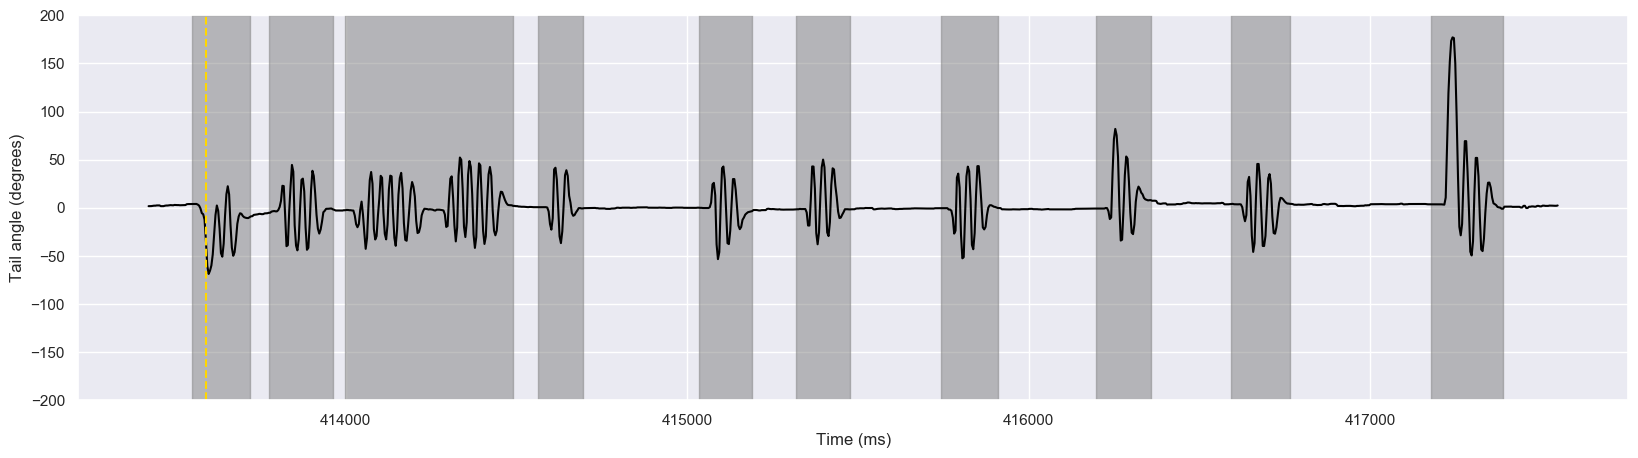

In [120]:
sns.lineplot(data=boi, x='time_ms', y="tip", legend='auto', color='black', zorder=2)
plt.ylim(-200, 200)
plt.xlabel('Time (ms)')
plt.ylabel('Tail angle (degrees)')

plt.axvline(x=413590.777543, linestyle='--', c='gold') # roughly where J-turn/eye convergence can be observed
# plt.axvline(x=33431, linestyle='--', c='royalblue') # fish midline aligned with target paramecium/ within binocular zone
# plt.axvline(x=33482, linestyle='--', c='blue')
# plt.axvline(x=16620, linestyle='--', c='tomato') # the first frame of when the paramecium enters the fish mouth/ capture strike (success/failure)
# plt.axvline(x=33537, linestyle='--', c='coral') # complete overshoot, paramecium is located directly above of one fish eye

# to shade the frames when a bout took place
for start, end in zip(bout_label_frames[::2], bout_label_frames[1::2]): # specify the first two items in the list as start and end respectively
    for i in range(len(start)):
        plt.axvspan(start[i], end[i], alpha=0.5, color='gray')

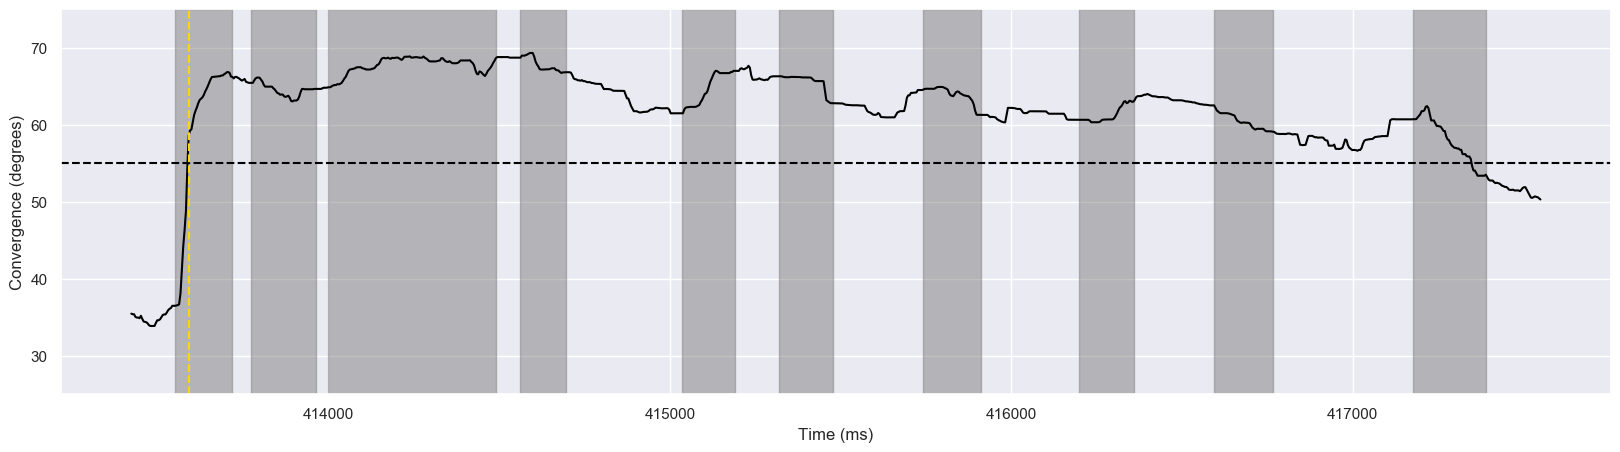

In [119]:
mask = boi['convergence'] > convergence_scores[convergence_scores['ID'] == ID].threshold.squeeze()

sns.lineplot(data=boi, x='time_ms', y="convergence", legend='auto', color='black', zorder=2)
plt.ylim(25, 75)
plt.xlabel('Time (ms)')
plt.ylabel('Convergence (degrees)')
plt.axhline(y=convergence_scores[convergence_scores['ID'] == ID].threshold.squeeze(), linestyle='--', c='black')

plt.axvline(x=413590.777543, linestyle='--', c='gold') # roughly where J-turn/eye convergence can be observed
# plt.axvline(x=33431, linestyle='--', c='royalblue') # fish midline aligned with target paramecium/ within binocular zone
# plt.axvline(x=33482, linestyle='--', c='blue')
# plt.axvline(x=16620, linestyle='--', c='tomato') # the first frame of when the paramecium enters the fish mouth/ capture strike (success/failure)
# plt.axvline(x=33537, linestyle='--', c='coral')

# to shade the frames when a bout took place
for start, end in zip(bout_label_frames[::2], bout_label_frames[1::2]): # specify the first two items in the list as start and end respectively
    for i in range(len(start)):
        plt.axvspan(start[i], end[i], alpha=0.5, color='gray')

In [107]:
boi

,index,ID,code,frame,speed,angular_velocity,tip,left_angle,right_angle,convergence,time,phase,bout_label,time_ms
103384,1003809,2025061203,2025061203151944.800,28346,196.253015,0.000000,1.653364,-21.061547,14.409755,35.471302,6.890380,NaN,NaN,413422.820273
103385,1003810,2025061203,2025061203151944.800,28347,375.403167,-1.613186,1.653364,-20.979378,14.409755,35.389132,6.890447,NaN,NaN,413426.819256
103386,1003811,2025061203,2025061203151944.800,28348,316.262046,0.000000,1.727307,-20.979378,14.409755,35.389132,6.890514,NaN,NaN,413430.818239
103387,1003812,2025061203,2025061203151944.800,28349,254.879734,2.549866,1.969238,-20.637012,14.409755,35.046767,6.890580,NaN,NaN,413434.817221
103388,1003813,2025061203,2025061203151944.800,28350,139.368896,0.000000,2.154692,-20.637012,14.321492,34.958504,6.890647,NaN,NaN,413438.816204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104412,1004837,2025061203,2025061203151944.800,29374,88.900318,1.059136,2.174820,-28.214776,22.485239,50.700015,6.958896,NaN,NaN,417533.774397
104413,1004838,2025061203,2025061203151944.800,29375,579.659580,0.173162,2.053452,-28.143593,22.485239,50.628832,6.958963,NaN,NaN,417537.773380
104414,1004839,2025061203,2025061203151944.800,29376,165.798947,0.000000,2.033609,-28.104907,22.485239,50.590146,6.959030,NaN,NaN,417541.772363
104415,1004840,2025061203,2025061203151944.800,29377,298.025266,-2.837160,2.033609,-28.076299,22.361204,50.437503,6.959096,NaN,NaN,417545.771345


#### Plot fish location over time

In [50]:
tracking = import_csvs(experiment.subdirs['tracking'], index_levels=(1,0), level_names=("ID", 'code', "frame"))
tracking = tracking.reset_index()
tracking['time'] = kinematics['time']
tracking['convergence'] = kinematics['convergence']
tracking

Opening 528 csv files...
########### 10%
########### 20%
############ 30%
########### 40%
########### 50%
########### 60%
########### 70%
############ 80%
########### 90%
########### 100%
#done!
DataFrame has shape: (19809223, 10).
Index levels: ('ID', 'code', 'frame').



,ID,code,frame,x,y,heading,left_x,left_y,left_angle,right_x,right_y,right_angle,tracked,time,convergence
0,2025061201,2025061201134603.404,0,988.026217,402.786517,1.408479,993.500000,429.000000,0.000000,990.121212,422.792208,1.277702,1.0,0.000000,NaN
1,2025061201,2025061201134603.404,1,988.026217,402.786517,1.408479,993.500000,429.000000,0.000000,990.121212,422.792208,1.277702,1.0,0.000067,NaN
2,2025061201,2025061201134603.404,2,988.026217,402.786517,1.408479,993.500000,429.000000,0.000000,990.121212,422.792208,1.277702,1.0,0.000133,NaN
3,2025061201,2025061201134603.404,3,988.026217,402.786517,1.408479,993.500000,429.000000,0.000000,990.121212,422.792208,1.277702,1.0,0.000200,NaN
4,2025061201,2025061201134603.404,4,988.026217,402.786517,1.407052,993.500000,429.000000,0.000000,990.181435,422.746835,1.295189,1.0,0.000267,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19809218,2025082209,2025082209221305.472,37511,442.684418,852.996055,-3.092399,420.552743,857.021097,3.440363,421.062271,846.816850,2.905696,1.0,30.004650,30.658274
19809219,2025082209,2025082209221305.472,37512,442.684418,852.996055,-3.092399,420.552743,857.021097,3.440363,421.062271,846.816850,2.905696,1.0,30.004717,30.658274
19809220,2025082209,2025082209221305.472,37513,442.684418,852.996055,-3.092399,420.552743,857.021097,3.440363,421.062271,846.816850,2.905696,1.0,30.004784,30.646205
19809221,2025082209,2025082209221305.472,37514,442.684418,852.996055,-3.092399,420.552743,857.021097,3.440363,421.062271,846.816850,2.905696,1.0,30.004850,30.634136


In [100]:
ID = '2025082108' # change ID number here
# define sub dataframe for one fish
sub_track = tracking[tracking['ID'] == ID].reset_index()
sub_track

,index,ID,code,frame,x,y,heading,left_x,left_y,left_angle,right_x,right_y,right_angle,tracked,time,convergence
0,14856954,2025082108,2025082108195734.299,0,423.886486,38.675676,2.848718,409.250000,43.500000,3.141593,399.919003,45.492212,3.164573,1.0,0.000000,-2.369784
1,14856955,2025082108,2025082108195734.299,1,423.938406,38.653986,2.843057,409.000000,43.750000,3.141593,400.003175,45.520635,3.131032,1.0,0.000067,-2.321538
2,14856956,2025082108,2025082108195734.299,2,423.938406,38.653986,2.843057,409.000000,43.750000,3.141593,400.003175,45.520635,3.131032,1.0,0.000133,-2.273292
3,14856957,2025082108,2025082108195734.299,3,423.938406,38.653986,2.843057,409.000000,43.750000,3.141593,400.003175,45.520635,3.131032,1.0,0.000200,-2.496710
4,14856958,2025082108,2025082108195734.299,4,423.858423,38.679211,2.843086,409.000000,43.750000,3.141593,400.003175,45.520635,3.131032,1.0,0.000267,-2.720128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450196,15307150,2025082108,2025082108202517.047,37514,764.917949,555.097436,-1.679592,756.808989,530.310861,-1.373558,767.454545,528.867424,4.283470,1.0,30.004750,36.003081
450197,15307151,2025082108,2025082108202517.047,37515,764.939173,553.982968,-1.686898,756.808989,530.310861,-1.373558,767.366300,528.754579,4.252801,1.0,30.004817,36.242826
450198,15307152,2025082108,2025082108202517.047,37516,765.173077,553.329060,-1.747720,755.682171,531.046512,-1.516771,766.348837,529.104651,4.117918,1.0,30.004883,36.213844
450199,15307153,2025082108,2025082108202517.047,37517,765.861272,553.504817,-1.887880,753.505882,533.015686,4.666261,763.587121,529.412879,3.926991,1.0,30.004950,36.184862


In [52]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import LineCollection


def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [53]:
import imagecodecs
import tifffile

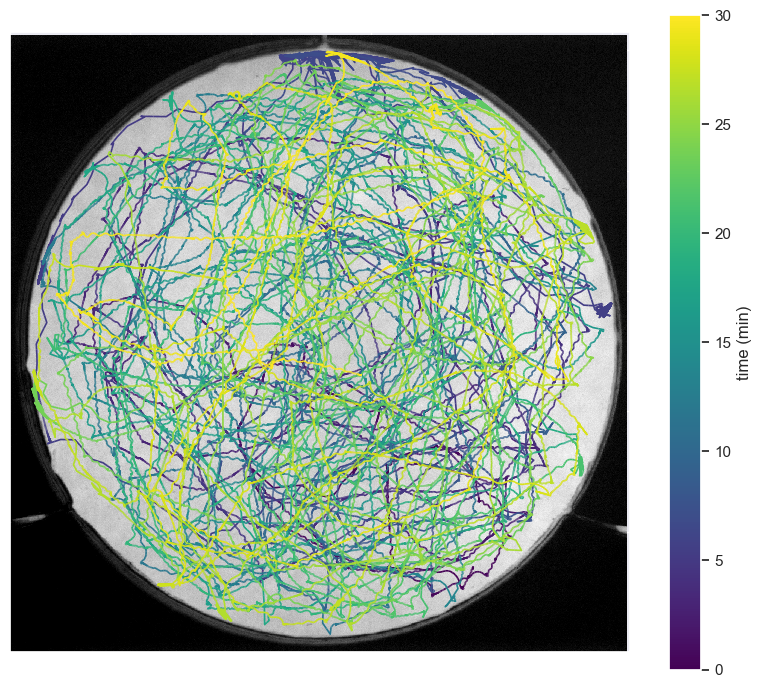

In [72]:
sns.set_theme(rc={"figure.figsize": (10,8.5)})

# Create a figure and plot the line on it
fig1, ax1 = plt.subplots()
lines = colored_line(sub_track.x, sub_track.y, sub_track.time, ax1, linewidth=1.2, cmap="viridis")
fig1.colorbar(lines, label='time (min)', ax=ax1)  # add a color legend

arena = tifffile.imread('mafaa_analysis/backgrounds/2025082109.tiff') # import background image
plt.imshow(arena, cmap='gray', zorder=1)

# Set the axis limits and tick positions
ax1.set_xlim(0, 1030)
ax1.set_ylim(0, 1030)
ax1.set_xticklabels([])
ax1.set_yticklabels([])
# ax1.set_title("Fish 3 (no ablation)")

plt.show()

In [124]:
convergence_scores[convergence_scores['ID'] == ID].threshold.squeeze()

51.0

In [125]:
norm_con = np.array(sub_track_seg['convergence']/convergence_scores[convergence_scores['ID'] == ID].threshold.squeeze())

In [128]:
sub_track_seg.describe()

,index,frame,x,y,heading,left_x,left_y,left_angle,right_x,right_y,right_angle,tracked,time,convergence,norm_con
count,7.502000e+04,75020.000000,75009.000000,75009.000000,75009.000000,75009.000000,75009.000000,75009.000000,75009.000000,75009.000000,75009.000000,75020.000000,75020.000000,74937.000000,74937.000000
mean,1.541968e+07,18754.503093,613.196619,587.904694,0.297032,612.357743,589.026646,1.626980,611.590504,588.921834,1.772143,0.999853,7.499971,29.262549,0.573775
std,2.165655e+04,10828.281819,199.436563,275.428283,1.867375,200.337710,277.394363,1.700003,200.199723,276.766554,1.737726,0.012108,1.443389,30.609735,0.600191
min,1.538218e+07,0.000000,42.344444,66.313725,-3.140992,34.444444,46.670370,-1.570333,40.550725,43.985507,-1.570459,0.000000,5.000047,-110.551098,-2.167669
25%,1.540093e+07,9377.000000,506.170022,346.312883,-1.356536,512.532567,335.423913,0.002910,510.000000,341.107639,0.163021,1.000000,6.249992,14.691799,0.288074
50%,1.541968e+07,18754.500000,622.618391,577.333333,0.402794,624.194719,567.000000,1.720949,622.500000,575.476190,1.969605,1.000000,7.500004,36.232463,0.710440
75%,1.543844e+07,28132.000000,752.784580,857.514925,2.137103,757.645833,871.112281,3.062420,752.166667,874.088889,3.141593,1.000000,8.749949,48.737579,0.955639
max,1.545719e+07,37517.000000,999.095238,998.000000,3.140899,1002.000000,998.000000,4.712389,999.500000,999.000000,4.712389,1.000000,9.999961,98.752117,1.936316


In [127]:
sub_track_seg.loc[:, 'norm_con'] = norm_con
sub_track_seg

c:\Users\manyung.ng\AppData\Local\anaconda3\envs\behavior_analysis\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


,index,ID,code,frame,x,y,heading,left_x,left_y,left_angle,right_x,right_y,right_angle,tracked,time,convergence,norm_con
75020,15382175,2025082109,2025082109204211.217,37504,226.856512,648.203091,1.245342,240.336806,670.895833,1.682668,229.996337,674.761905,1.219219,1.0,5.000047,23.821025,0.467079
75021,15382176,2025082109,2025082109204211.217,37505,226.796909,648.289183,1.241941,240.468750,671.052083,1.552397,229.940075,674.801498,1.207976,1.0,5.000114,23.849791,0.467643
75022,15382177,2025082109,2025082109204211.217,37506,227.000000,648.804825,1.242162,240.479592,671.197279,1.509885,230.162791,675.217054,1.228830,1.0,5.000181,23.720425,0.465106
75023,15382178,2025082109,2025082109204211.217,37507,227.211538,649.175214,1.246861,240.500000,671.500000,1.570796,230.162791,675.217054,1.228830,1.0,5.000247,23.618766,0.463113
75024,15382179,2025082109,2025082109204211.217,37508,227.176344,649.126882,1.248451,240.532646,671.642612,1.533775,230.104651,675.368217,1.218213,1.0,5.000314,23.416507,0.459147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150035,15457190,2025082109,2025082109204713.494,37485,359.739700,529.376404,0.891732,379.043478,544.586957,1.381077,370.611722,551.553114,0.556404,1.0,9.999695,46.707284,0.915829
150036,15457191,2025082109,2025082109204713.494,37486,359.444444,529.208333,0.887346,379.043478,544.586957,1.381077,370.577778,551.566667,0.571438,1.0,9.999761,46.581628,0.913365
150037,15457192,2025082109,2025082109204713.494,37487,359.739700,529.376404,0.891732,379.043478,544.586957,1.381077,370.611722,551.553114,0.556404,1.0,9.999828,46.534682,0.912445
150038,15457193,2025082109,2025082109204713.494,37488,359.444444,529.208333,0.887346,379.043478,544.586957,1.381077,370.577778,551.566667,0.571438,1.0,9.999895,46.613392,0.913988


#### Plot eye convergence angle with fish location in the arena

In [122]:
ID = '2025082109' # change ID number here
# define sub dataframe for one fish
sub_track = tracking[tracking['ID'] == ID].reset_index()

In [59]:
# select a particular 2.5 min recording
code = sub_track['code'].unique()
code = code[2]
sub_track_seg = sub_track[sub_track['code'] == code]

In [123]:
# plot any selected time period
sub_track_seg = sub_track[(sub_track['time'] >= 5.0) & (sub_track['time'] <= 10.0)]

In [ ]:
# set range of colour bar
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=-0.5, vmax=2.5)
# norm = mcolors.Normalize(vmin=20, vmax=80) # just for vergence angle
mappable = cm.ScalarMappable(norm=norm)

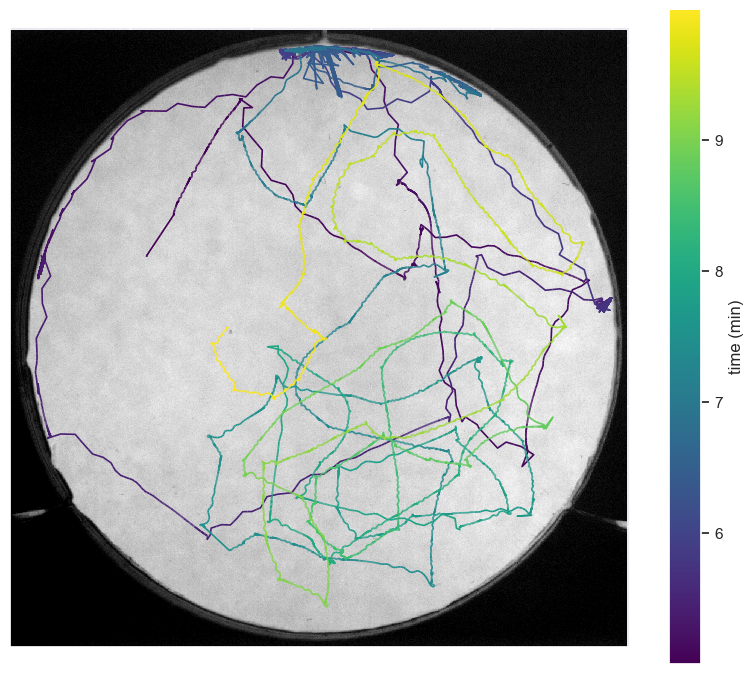

In [130]:
sns.set_theme(rc={"figure.figsize": (10,8.5)})

# Create a figure and plot the line on it
fig1, ax1 = plt.subplots()
lines = colored_line(sub_track_seg.x, sub_track_seg.y, sub_track_seg.time, ax1, linewidth=1.2, cmap="viridis")
fig1.colorbar(lines, label='time (min)', ax=ax1)  # add a color legend

arena = tifffile.imread('mafaa_analysis/backgrounds/2025082109.tiff') # import background image
plt.imshow(arena, cmap='gray', zorder=1)

# Set the axis limits and tick positions
ax1.set_xlim(0, 1030)
ax1.set_ylim(0, 1030)
ax1.set_xticklabels([])
ax1.set_yticklabels([])
# ax1.set_title("Fish 3 (no ablation)")

plt.show()

c:\Users\manyung.ng\AppData\Local\anaconda3\envs\behavior_analysis\lib\site-packages\matplotlib\colors.py:527: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


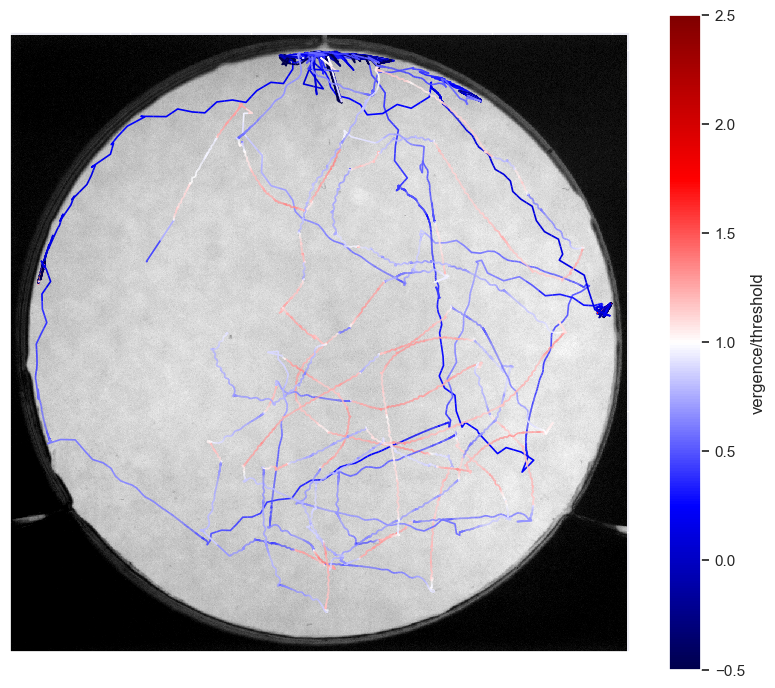

In [131]:
sns.set_theme(rc={"figure.figsize": (10,8.5)})

# Create a figure and plot the line on it
fig1, ax1 = plt.subplots()
lines = colored_line(sub_track_seg.x, sub_track_seg.y, sub_track_seg.norm_con, ax1, linewidth=1.2, cmap='seismic', norm=norm)
fig1.colorbar(lines, label='vergence/threshold')  # add a color legend

arena = tifffile.imread('mafaa_analysis/backgrounds/2025082109.tiff') # import background image
plt.imshow(arena, cmap='gray', zorder=1)

# Set the axis limits and tick positions
ax1.set_xlim(0, 1030)
ax1.set_ylim(0, 1030)
ax1.set_xticklabels([])
ax1.set_yticklabels([])
# ax1.set_title("Fish 8 (ablation)")

plt.show()